# Load package

In [9]:
import scimap as sm

import sys
import anndata as ad
import seaborn as sns; sns.set(color_codes=True)
import numpy as np

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


from scipy.stats import ttest_rel
import itertools


# survival analysis
#!pip install lifelines matplotlib
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy.stats import wilcoxon

# Load data

In [10]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_39660/1161626377.py:1: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



# Tumor state

In [13]:
data_tumor = data[data['celltype_1'] == 'Tumor']

In [14]:
data_tumor['GCLC_VIM'].value_counts()

GCLC_VIM
Tumor.GCLC-VIM-    1283619
Tumor.GCLC+VIM+     204468
Tumor.GCLC-VIM+     175805
Tumor.GCLC+VIM-     109268
Name: count, dtype: int64

In [5]:
df = data_tumor[['RCNs', 'GCLC_VIM']]

# Group the data by RCNs and celltype columns
count_df = df.groupby(['RCNs', 'GCLC_VIM']).size().unstack(fill_value=0)

# Get the total counts of each RPD
total_counts = df['RCNs'].value_counts().sort_index()
# Calculate the percentage of each cell type in each RPD
percent_df = count_df.div(total_counts, axis=0) * 100

# Create a custom order based on cell types
custom_order = ['Tumor.GCLC-VIM-', 'Tumor.GCLC-VIM+', 'Tumor.GCLC+VIM-', 'Tumor.GCLC+VIM+']

# Reorder the columns according to the custom_order
percent_df = percent_df.reindex(columns=custom_order)
# Sort the RCNs numerically
sorted_rcns = sorted(percent_df.index, key=lambda x: int(x[3:]) if x[3:].isdigit() else float('inf'))
percent_df = percent_df.reindex(sorted_rcns)

In [6]:
count_df

GCLC_VIM,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,Tumor.GCLC-VIM+,Tumor.GCLC-VIM-
RCNs,,,,
RCN1,126056,78735,104501,961558
RCN10,2056,635,3060,13096
RCN2,57506,23006,52487,250171
RCN3,1724,2392,1841,27221
RCN4,7082,479,5852,4715
RCN5,2825,468,1908,6006
RCN6,2062,803,1544,4821
RCN7,1397,122,1932,4449
RCN8,663,123,196,1302


In [7]:
percent_df

GCLC_VIM,Tumor.GCLC-VIM-,Tumor.GCLC-VIM+,Tumor.GCLC+VIM-,Tumor.GCLC+VIM+
RCNs,,,,
RCN1,75.662588,8.222922,6.195460,9.919031
RCN2,65.289819,13.698097,6.004123,15.007960
RCN3,82.045331,5.548858,7.209597,5.196214
RCN4,26.009488,32.281553,2.642321,39.066637
RCN5,53.591505,17.025074,4.175961,25.207460
RCN6,52.231853,16.728061,8.699892,22.340195
RCN7,56.316456,24.455696,1.544304,17.683544
RCN8,57.005254,8.581436,5.385289,29.028021
RCN9,55.972994,13.524992,13.639334,16.862681


# Percentage

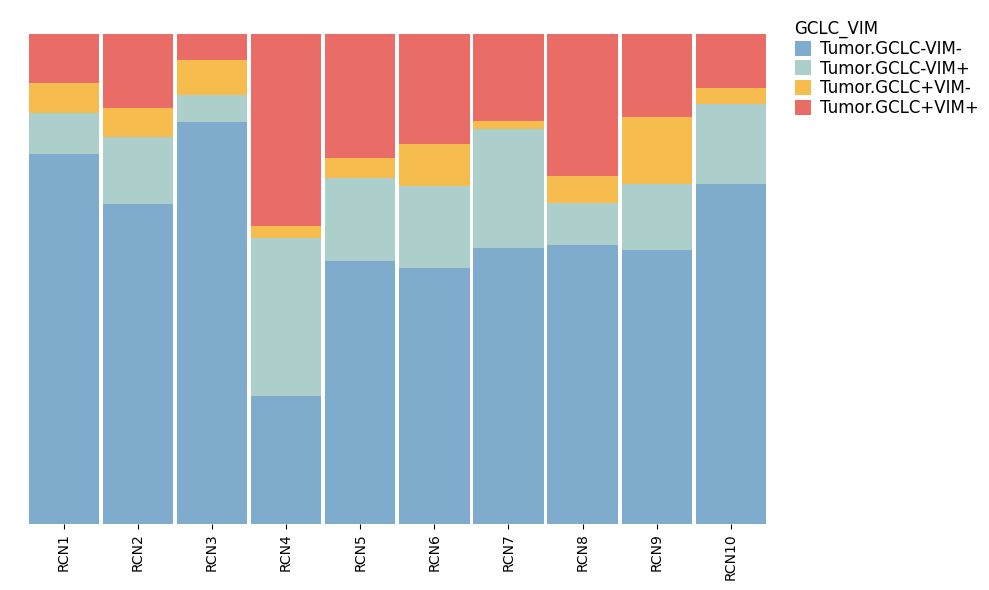

In [15]:


# Define colors for each cell type
colors_dict = {
    'Tumor.GCLC-VIM-': '#7FACCC',
    'Tumor.GCLC-VIM+': '#ADCFCB',
    'Tumor.GCLC+VIM-': '#F6BD4E',
    'Tumor.GCLC+VIM+': '#E96C66'
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
percent_df.plot(kind='bar', stacked=True, color=[colors_dict.get(x) for x in percent_df.columns], 
                ax=ax, width=0.95, edgecolor='none')

# Add the legend outside the plot
legend = plt.legend(title='GCLC_VIM', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
#legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

for spine in ax.spines.values():
    spine.set_visible(False)
plt.yticks([]) 

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xticks(rotation=90)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/GCLC_VIM_by_RCNs.pdf', bbox_inches='tight', dpi=500)
plt.show()

# counts

In [16]:
count_df_sub = count_df[['Tumor.GCLC+VIM+']]
count_df_sub = count_df_sub.sort_values(by='Tumor.GCLC+VIM+', ascending=False)
count_df_sub

GCLC_VIM,Tumor.GCLC+VIM+
RCNs,
RCN1,126056
RCN2,57506
RCN4,7082
RCN9,3097
RCN5,2825
RCN6,2062
RCN10,2056
RCN3,1724
RCN7,1397


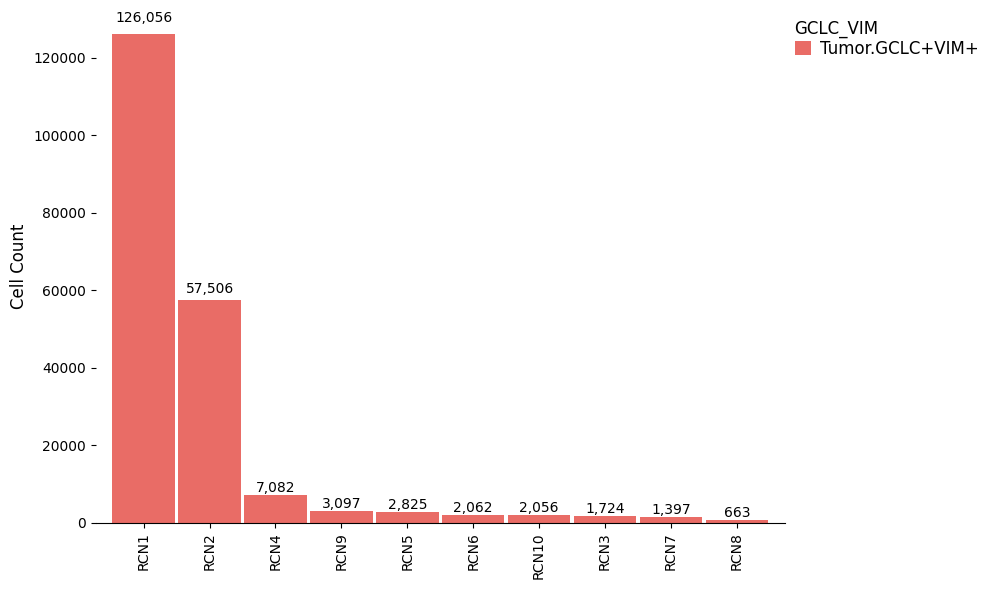

In [19]:
# Define colors for each cell type
colors_dict = {
    'Tumor.GCLC+VIM+': '#E96C66'
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
count_df_sub.plot(kind='bar', stacked=True, color=[colors_dict.get(x) for x in count_df_sub.columns], 
                ax=ax, width=0.95, edgecolor='none')

# Add count values on top of each bar
for i, value in enumerate(count_df_sub['Tumor.GCLC+VIM+']):
    ax.text(i, value * 1.02, f'{value:,}', ha='center', va='bottom', fontsize=10)

# Add the legend outside the plot
legend = plt.legend(title='GCLC_VIM', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

# Set visible y-ticks
plt.yticks(fontsize=10)

for spine in ax.spines.values():
    if spine.spine_type != 'bottom':
        spine.set_visible(False)

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('Cell Count', fontsize=12)
plt.xticks(rotation=90)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/GCLC_VIM_by_RCNs_count.pdf', bbox_inches='tight', dpi=500)
plt.show()

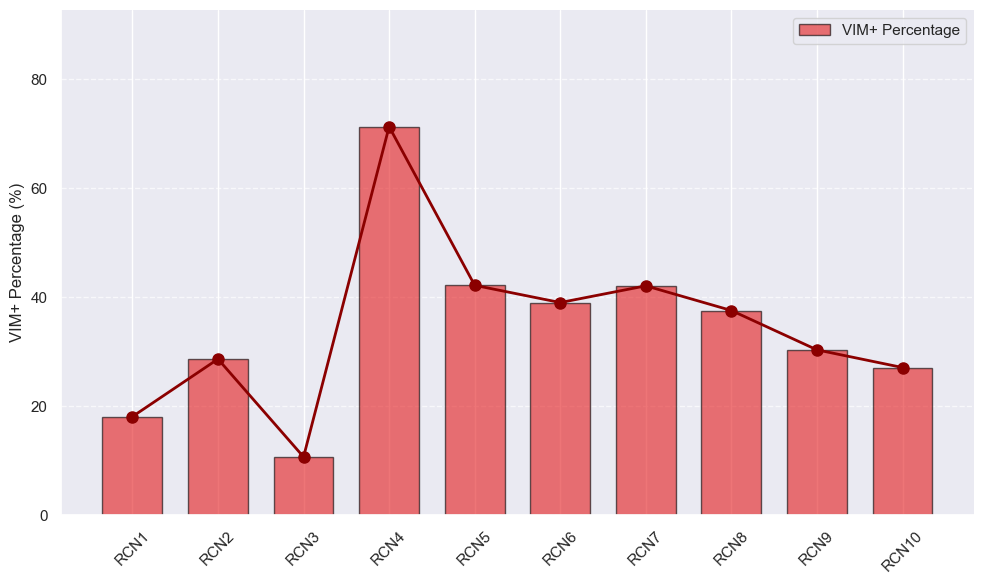

In [13]:
vimplus_data = percent_df['VIM+']
tumor_data = percent_df['Tumor']

# Create a list of sorted RCNs for x-axis
sorted_rcns = percent_df.index.tolist()

# Create rcn_indices to map RCNs to their position in the plot
rcn_indices = {rcn: i for i, rcn in enumerate(sorted_rcns)}

# Create a color dictionary for consistency
colors_dict = {'VIM+': '#E41A1C', 'Tumor': '#4DAF4A'}

# Create a figure with both bar and line plots
fig, ax = plt.subplots(figsize=(10, 6))

# Create x positions for RCNs
x_pos = np.arange(len(sorted_rcns))

# Plot VIM+ percentages as bars
# Plot VIM+ percentages as bars
ax.bar(x_pos, vimplus_data, color=colors_dict['VIM+'], alpha=0.6, width=0.7, 
        edgecolor='black', label='VIM+ Percentage')

# Plot VIM+ percentages with line and markers
ax.plot(x_pos, vimplus_data, color='darkred', marker='o', markersize=8, 
         linewidth=2, zorder=3)

# Add Tumor percentages as second bars (optional - comment out if not needed)
#ax.bar(x_pos, tumor_data, color=colors_dict['Tumor'], alpha=0.6, width=0.7,
#        edgecolor='black', label='Tumor Percentage')

# Add legend
ax.legend(loc='upper right')

# Set chart labels and styling
ax.set_ylabel('VIM+ Percentage (%)', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(sorted_rcns, rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis limit to accommodate significance arcs
ax.set_ylim(0, max(vimplus_data) * 1.3)

plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/tumor_state_by_RCNs_vimplus_2.pdf', 
            bbox_inches='tight', dpi=500)
plt.show()


# Combined

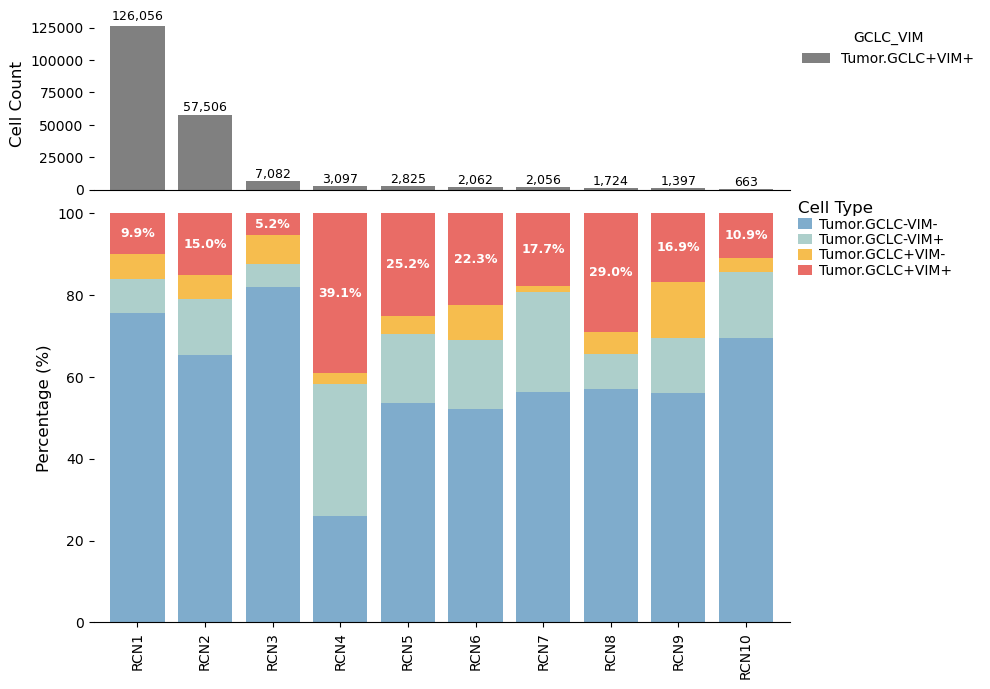

In [38]:
# Sort the count_df for the top plot
count_df_sub = count_df[['Tumor.GCLC+VIM+']]
count_df_sub = count_df_sub.sort_values(by='Tumor.GCLC+VIM+', ascending=False)

# Define colors for each cell type
colors_dict = {
    'Tumor.GCLC-VIM-': '#7FACCC',
    'Tumor.GCLC-VIM+': '#ADCFCB',
    'Tumor.GCLC+VIM-': '#F6BD4E',
    'Tumor.GCLC+VIM+': '#E96C66'
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[0.6, 1.5])

# Top subplot (count plot with gray color)
count_df_sub.plot(kind='bar', color='gray', ax=ax1, width=0.8, edgecolor='none')

# Add count values on top of each bar
for i, value in enumerate(count_df_sub['Tumor.GCLC+VIM+']):
    ax1.text(i, value * 1.02, f'{value:,}', ha='center', va='bottom', fontsize=9)

# Remove spines from top plot
for spine in ax1.spines.values():
    if spine.spine_type != 'bottom':
        spine.set_visible(False)

ax1.set_ylabel('Cell Count', fontsize=12)
ax1.set_title('', fontsize=14)
ax1.set_xlabel('')
# remove x-ticks and labels
ax1.tick_params(axis='x', bottom=False, labelbottom=False)
# add legend for the top plot
ax1.legend(['Tumor.GCLC+VIM+'], title='GCLC_VIM', 
           bbox_to_anchor=(1.0, 1), loc='upper left', 
           fontsize=10, frameon=False)



# Bottom subplot (stacked percentage plot)
percent_df.plot(kind='bar', stacked=True, 
                color=[colors_dict.get(x) for x in percent_df.columns], 
                ax=ax2, width=0.8, edgecolor='none')

# Add percentage values for GCLC+VIM+ (last segment in each stack)
for i, value in enumerate(percent_df['Tumor.GCLC+VIM+']):
    # Calculate the bottom position (sum of other segments)
    bottom = percent_df.iloc[i, 0:3].sum()
    # Add the text in the middle of the segment
    ax2.text(i, bottom + value/2, f'{value:.1f}%', ha='center', va='center', 
             fontsize=9, fontweight='bold', color='white')

# Add the legend to the bottom plot
legend = ax2.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=10,
           frameon=False,
           handleheight=0.8, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
legend.get_title().set_fontsize(12)
legend._legend_box.align = "left"

# Remove spines from bottom plot
for spine in ax2.spines.values():
    if spine.spine_type != 'bottom':
        spine.set_visible(False)

ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_xlabel('', fontsize=12)
ax2.tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.01)

# Show the figure
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/GCLC_VIM_by_RCNs_combined.pdf', 
            bbox_inches='tight', dpi=500)
plt.show()

# Survival curve

In [15]:
data_tumor.columns

Index(['S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4', 'FOXP3',
       'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin', 'H3K27me3',
       'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN', 'pSTAT3',
       'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid', 'imageid',
       'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI',
       'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1',
       'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM',
       'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs'],
      dtype='object')

In [17]:
data_tumor['Annotation'].value_counts()

Annotation
Tumor center       997359
Invasive border    367796
Inflammation       210539
Lymph node met     197466
Name: count, dtype: int64

In [33]:
df = data_tumor[['patient_id_AB19_1654', 'GCLC_VIM']]

In [34]:

count_df = df.groupby(['patient_id_AB19_1654', 'GCLC_VIM']).size().unstack(fill_value=0)
total_counts = df['patient_id_AB19_1654'].value_counts().sort_index()
percent_df = count_df.div(total_counts, axis=0) * 100
custom_order = ['Tumor.GCLC-VIM-', 'Tumor.GCLC-VIM+', 'Tumor.GCLC+VIM-', 'Tumor.GCLC+VIM+']
percent_df = percent_df.reindex(columns=custom_order)


In [23]:
clinical_data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/clinical_data_per_core.csv', index_col=0)
df_clinical_data = clinical_data[['imageid', 'Stage', 'status', 'time', 'rounded_age']]
df_clinical_data['patient_id'] = df_clinical_data.index
df_clinical_data = df_clinical_data.drop_duplicates(subset='patient_id')

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_39660/1218027691.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [24]:
df_clinical_data

,imageid,Stage,status,time,rounded_age,patient_id
patient_id_AB19_1654,,,,,,
AB19-1654_P10078,19_02_01A,2,0,8.561494,54.0,AB19-1654_P10078
AB19-1654_P10079,19_02_01A,1,0,8.525901,56.0,AB19-1654_P10079
AB19-1654_P10080,19_02_01A,4,1,0.177965,71.0,AB19-1654_P10080
AB19-1654_P10081,19_02_01A,2,1,0.347717,73.0,AB19-1654_P10081
AB19-1654_P10082,19_02_01A,1,0,8.490308,66.0,AB19-1654_P10082
...,...,...,...,...,...,...
AB19-1654_P10704,INF2,1,0,18.585040,43.0,AB19-1654_P10704
AB19-1654_P10707,M1,2,0,18.420764,49.0,AB19-1654_P10707
AB19-1654_P10708,M1,2,0,18.152448,57.0,AB19-1654_P10708


## High30 VS Low5

In [ ]:
# Filter patients where Tumor.GCLC+VIM+ percentage >= 30% or <= 5%
high_GCLC_VIM_patients = percent_df[percent_df['Tumor.GCLC+VIM+'] >= 30]
high_GCLC_VIM_patients['G_V_group'] = 'High'
low_GCLC_VIM_patients = percent_df[percent_df['Tumor.GCLC+VIM+'] <= 5]
low_GCLC_VIM_patients['G_V_group'] = 'Low'

# Combine both sets of patients
filtered_patients = pd.concat([high_GCLC_VIM_patients, low_GCLC_VIM_patients])
filtered_patients = filtered_patients.sort_values(by='Tumor.GCLC+VIM+', ascending=False)


df_patients = filtered_patients[['Tumor.GCLC+VIM+', 'G_V_group']]
df_patients['patient_id'] = df_patients.index

df_clinical_GV = pd.merge(df_patients, df_clinical_data, on='patient_id', how='left')
df_clinical_GV

In [65]:
df_clinical_GV['G_V_group'].value_counts()

G_V_group
Low     66
High    21
Name: count, dtype: int64

In [66]:
df_clinical_GV['status'].unique()

array([0, 1])

In [68]:
df_clinical_GV['Stage'].value_counts()

Stage
2          48
1          18
unknown    12
3           9
Name: count, dtype: int64

In [67]:
df_clinical_GV

,Tumor.GCLC+VIM+,G_V_group,patient_id,imageid,Stage,status,time,rounded_age
0,89.994188,High,AB19-1654_P10135,19_02_02A,2,0,4.870770,30.0
1,77.952756,High,AB19-1654_P10410,INF2,1,0,16.066148,60.0
2,76.975590,High,AB19-1654_P10690,INF1,unknown,1,10.738145,80.0
3,66.843265,High,AB19-1654_P10123,19_02_02A,2,0,5.582631,69.0
4,64.213580,High,AB19-1654_P10623,3B,2,0,8.931114,68.0
...,...,...,...,...,...,...,...,...
82,0.316406,Low,AB19-1654_P10171,19_02_03A,2,0,2.973387,70.0
83,0.277079,Low,AB19-1654_P10177,19_02_03A,2,0,2.669478,35.0
84,0.100746,Low,AB19-1654_P10167,19_02_03A,2,0,3.126711,75.0
85,0.071531,Low,AB19-1654_P10096,19_02_01A,2,0,7.009090,47.0


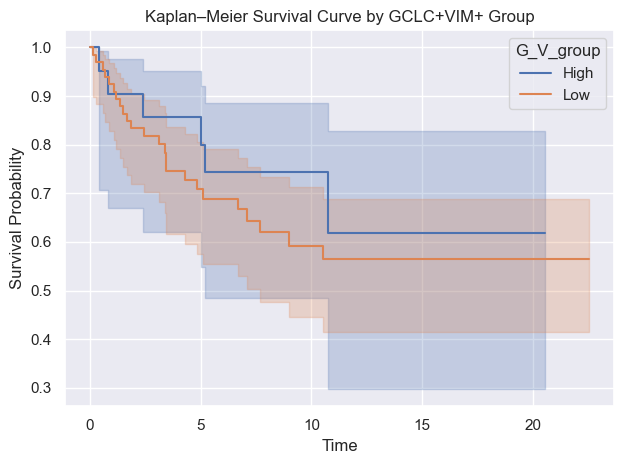

In [ ]:
df = df_clinical_GV.copy()
kmf = KaplanMeierFitter()
fig, ax = plt.subplots()

# Fit the Kaplan-Meier estimator for each group
for group in df['G_V_group'].unique():
    mask = df['G_V_group'] == group
    kmf.fit(df[mask]['time'], df[mask]['status'], label=group)
    kmf.plot_survival_function(ax=ax)

# Customize the plot
plt.title("Kaplan-Meier Survival Curve by GCLC+VIM+ Group")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend(title="G_V_group")
plt.tight_layout()
plt.show()


In [ ]:

df_high = df[df['G_V_group'] == 'High']
df_low = df[df['G_V_group'] == 'Low']

results = logrank_test(
    df_high['time'], df_low['time'],
    event_observed_A=df_high['status'],
    event_observed_B=df_low['status']
)

print("Log-rank test p-value:", results.p_value)


Log-rank test p-value: 0.4730261719125983


## 15%

In [ ]:
# Calculate the threshold values for top 15% and bottom 15%
high_threshold = percent_df['Tumor.GCLC+VIM+'].quantile(0.85)  # Top 15%
low_threshold = percent_df['Tumor.GCLC+VIM+'].quantile(0.15)   # Bottom 15%

# Filter patients where Tumor.GCLC+VIM+ percentage is in the top 15% or bottom 15%
high_GCLC_VIM_patients = percent_df[percent_df['Tumor.GCLC+VIM+'] >= high_threshold]
high_GCLC_VIM_patients['G_V_group'] = 'High'
low_GCLC_VIM_patients = percent_df[percent_df['Tumor.GCLC+VIM+'] <= low_threshold]
low_GCLC_VIM_patients['G_V_group'] = 'Low'

# Combine both sets of patients
filtered_patients = pd.concat([high_GCLC_VIM_patients, low_GCLC_VIM_patients])
filtered_patients = filtered_patients.sort_values(by='Tumor.GCLC+VIM+', ascending=False)


df_patients = filtered_patients[['Tumor.GCLC+VIM+', 'G_V_group']]
df_patients['patient_id'] = df_patients.index

df_clinical_GV = pd.merge(df_patients, df_clinical_data, on='patient_id', how='left')
df_clinical_GV

In [54]:
df_clinical_GV.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/clinical_data_GCLC_VIM.csv', index=False)

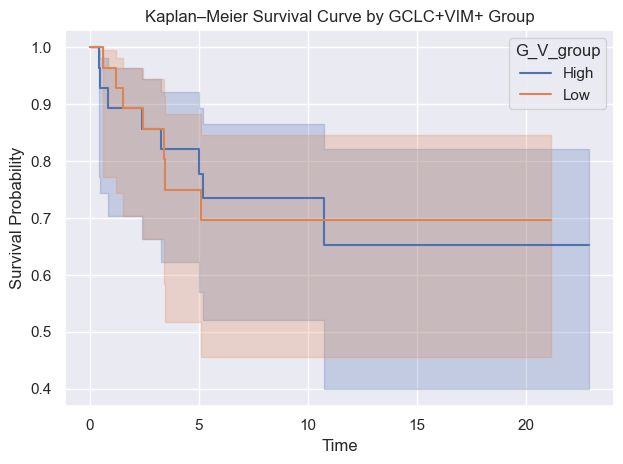

In [46]:
df = df_clinical_GV.copy()
kmf = KaplanMeierFitter()
fig, ax = plt.subplots()

# Fit the Kaplan-Meier estimator for each group
for group in df['G_V_group'].unique():
    mask = df['G_V_group'] == group
    kmf.fit(df[mask]['time'], df[mask]['status'], label=group)
    kmf.plot_survival_function(ax=ax)

# Customize the plot
plt.title("Kaplan–Meier Survival Curve by GCLC+VIM+ Group")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend(title="G_V_group")
plt.tight_layout()
plt.show()

In [ ]:

df_high = df[df['G_V_group'] == 'High']
df_low = df[df['G_V_group'] == 'Low']

# log-rank test
results = logrank_test(
    df_high['time'], df_low['time'],
    event_observed_A=df_high['status'],
    event_observed_B=df_low['status']
)

print("Log-rank test p-value:", results.p_value)

Log-rank test p-value: 0.9904579334306156


In [61]:
test = df_low['time']

# Cox Harzard Model

In [ ]:
data_tumor_inflammation = data_tumor[data_tumor['Annotation'] == 'Inflammation']
df = data_tumor_inflammation[['patient_id_AB19_1654', 'GCLC_VIM']]
count_df = df.groupby(['patient_id_AB19_1654', 'GCLC_VIM']).size().unstack(fill_value=0)
total_counts = df['patient_id_AB19_1654'].value_counts().sort_index()
percent_df = count_df.div(total_counts, axis=0) * 100
custom_order = ['Tumor.GCLC-VIM-', 'Tumor.GCLC-VIM+', 'Tumor.GCLC+VIM-', 'Tumor.GCLC+VIM+']
percent_df = percent_df.reindex(columns=custom_order)

percent_df['patient_id'] = percent_df.index
percent_df

GCLC_VIM,Tumor.GCLC-VIM-,Tumor.GCLC-VIM+,Tumor.GCLC+VIM-,Tumor.GCLC+VIM+,patient_id
patient_id_AB19_1654,,,,,
AB19-1654_P10410,4.593176,15.354331,2.099738,77.952756,AB19-1654_P10410
AB19-1654_P10456,92.838323,6.347305,0.119760,0.694611,AB19-1654_P10456
AB19-1654_P10534,91.433483,0.420208,3.934677,4.211632,AB19-1654_P10534
AB19-1654_P10535,63.056558,0.000000,32.611312,4.332130,AB19-1654_P10535
AB19-1654_P10536,89.738127,0.266312,8.486462,1.509099,AB19-1654_P10536
...,...,...,...,...,...
AB19-1654_P10701,92.290340,0.371550,1.141189,6.196921,AB19-1654_P10701
AB19-1654_P10702,50.939376,0.464846,32.190587,16.405191,AB19-1654_P10702
AB19-1654_P10704,98.005319,0.598404,0.709220,0.687057,AB19-1654_P10704


In [83]:
#percent_df['Tumor.GCLC+VIM+'] = pd.to_numeric(percent_df['Tumor.GCLC+VIM+'], errors='coerce')

threshold_1 = percent_df['Tumor.GCLC+VIM+'].quantile(0.25)
threshold_2 = percent_df['Tumor.GCLC+VIM+'].quantile(0.5)  
threshold_3 = percent_df['Tumor.GCLC+VIM+'].quantile(0.75)

percent_df.loc[(percent_df['Tumor.GCLC+VIM+'] < threshold_1), 'G_V_Group'] = 'Quarter_1'
percent_df.loc[(percent_df['Tumor.GCLC+VIM+'] >= threshold_1) & (percent_df['Tumor.GCLC+VIM+'] < threshold_2), 'G_V_Group'] = 'Quarter_2'
percent_df.loc[(percent_df['Tumor.GCLC+VIM+'] >= threshold_2) & (percent_df['Tumor.GCLC+VIM+'] < threshold_3), 'G_V_Group'] = 'Quarter_3'
percent_df.loc[(percent_df['Tumor.GCLC+VIM+'] >= threshold_3), 'G_V_Group'] = 'Quarter_4'


In [84]:
percent_df

GCLC_VIM,Tumor.GCLC-VIM-,Tumor.GCLC-VIM+,Tumor.GCLC+VIM-,Tumor.GCLC+VIM+,patient_id,G_V_Group
patient_id_AB19_1654,,,,,,
AB19-1654_P10410,4.593176,15.354331,2.099738,77.952756,AB19-1654_P10410,Quarter_4
AB19-1654_P10456,92.838323,6.347305,0.119760,0.694611,AB19-1654_P10456,Quarter_1
AB19-1654_P10534,91.433483,0.420208,3.934677,4.211632,AB19-1654_P10534,Quarter_2
AB19-1654_P10535,63.056558,0.000000,32.611312,4.332130,AB19-1654_P10535,Quarter_2
AB19-1654_P10536,89.738127,0.266312,8.486462,1.509099,AB19-1654_P10536,Quarter_1
...,...,...,...,...,...,...
AB19-1654_P10701,92.290340,0.371550,1.141189,6.196921,AB19-1654_P10701,Quarter_2
AB19-1654_P10702,50.939376,0.464846,32.190587,16.405191,AB19-1654_P10702,Quarter_3
AB19-1654_P10704,98.005319,0.598404,0.709220,0.687057,AB19-1654_P10704,Quarter_1


In [86]:
percent_df['G_V_Group'].value_counts()

G_V_Group
Quarter_4    16
Quarter_1    15
Quarter_2    15
Quarter_3    15
Name: count, dtype: int64

In [60]:
df_clinical_data

,imageid,Stage,status,time,rounded_age,patient_id
patient_id_AB19_1654,,,,,,
AB19-1654_P10078,19_02_01A,2,0,8.561494,54.0,AB19-1654_P10078
AB19-1654_P10079,19_02_01A,1,0,8.525901,56.0,AB19-1654_P10079
AB19-1654_P10080,19_02_01A,4,1,0.177965,71.0,AB19-1654_P10080
AB19-1654_P10081,19_02_01A,2,1,0.347717,73.0,AB19-1654_P10081
AB19-1654_P10082,19_02_01A,1,0,8.490308,66.0,AB19-1654_P10082
...,...,...,...,...,...,...
AB19-1654_P10704,INF2,1,0,18.585040,43.0,AB19-1654_P10704
AB19-1654_P10707,M1,2,0,18.420764,49.0,AB19-1654_P10707
AB19-1654_P10708,M1,2,0,18.152448,57.0,AB19-1654_P10708


In [87]:
df_clinical_GV = pd.merge(percent_df, df_clinical_data, on='patient_id', how='left')
df_clinical_GV

,Tumor.GCLC-VIM-,Tumor.GCLC-VIM+,Tumor.GCLC+VIM-,Tumor.GCLC+VIM+,patient_id,G_V_Group,imageid,Stage,status,time,rounded_age
0,4.593176,15.354331,2.099738,77.952756,AB19-1654_P10410,Quarter_4,INF2,1,0,16.066148,60.0
1,92.838323,6.347305,0.119760,0.694611,AB19-1654_P10456,Quarter_1,INF1,1,0,21.164166,40.0
2,91.433483,0.420208,3.934677,4.211632,AB19-1654_P10534,Quarter_2,1B,2,0,18.327675,61.0
3,63.056558,0.000000,32.611312,4.332130,AB19-1654_P10535,Quarter_2,1B,1,0,18.193517,59.0
4,89.738127,0.266312,8.486462,1.509099,AB19-1654_P10536,Quarter_1,INF2,unknown,1,0.856971,57.0
...,...,...,...,...,...,...,...,...,...,...,...
56,92.290340,0.371550,1.141189,6.196921,AB19-1654_P10701,Quarter_2,INF2,1,0,18.757529,63.0
57,50.939376,0.464846,32.190587,16.405191,AB19-1654_P10702,Quarter_3,INF2,2,1,12.254956,80.0
58,98.005319,0.598404,0.709220,0.687057,AB19-1654_P10704,Quarter_1,INF2,1,0,18.585040,43.0
59,91.902834,3.913630,1.754386,2.429150,AB19-1654_P10710,Quarter_1,INF2,2,0,13.259774,58.0


In [88]:
df_clinical_GV.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/clinical_data_GCLC_VIM_quarter.csv', index=False)

## 25%

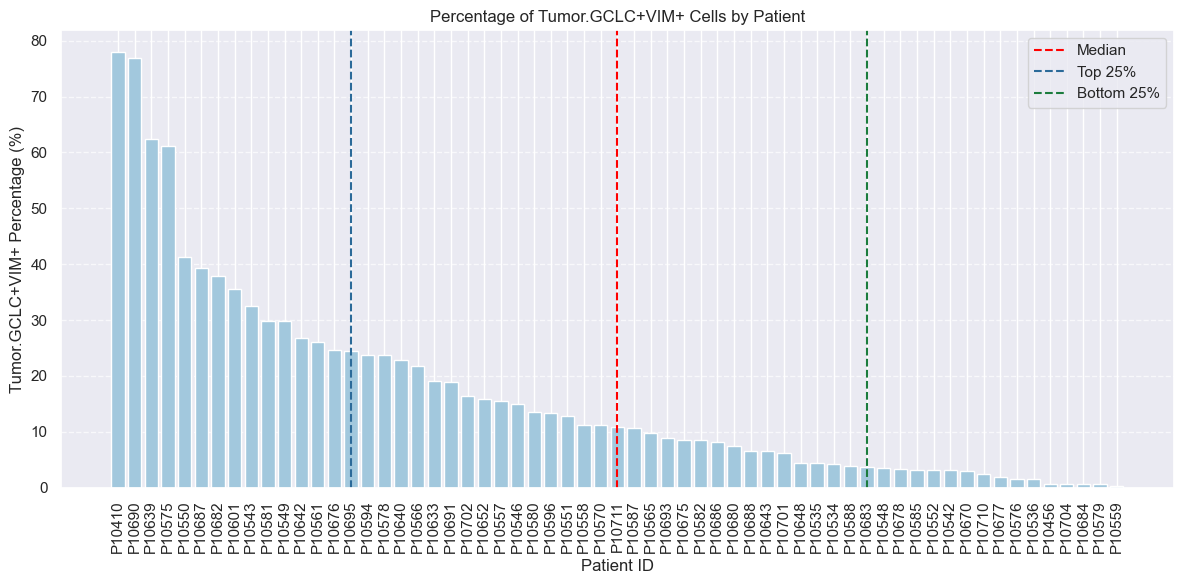

In [ ]:
# Extract Tumor.GCLC+VIM+ percentages
gclc_vim_percentages = percent_df['Tumor.GCLC+VIM+']
gclc_vim_percentages_sorted = gclc_vim_percentages.sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(gclc_vim_percentages_sorted)), gclc_vim_percentages_sorted.values, color='#A2C8DD')

# Add patient IDs as x-tick labels (shortened for readability)
shortened_ids = [pid.split('_')[1] for pid in gclc_vim_percentages_sorted.index]
plt.xticks(range(len(gclc_vim_percentages_sorted)), shortened_ids, rotation=90)

# Add labels and title
plt.xlabel('Patient ID')
plt.ylabel('Tumor.GCLC+VIM+ Percentage (%)')
plt.title('Percentage of Tumor.GCLC+VIM+ Cells by Patient')

# Add vertical lines
n = len(gclc_vim_percentages_sorted)
median_index = n // 2                      
top_25_index = int(n * 0.25) - 1
bottom_25_index = int(n * 0.75)   

plt.axvline(x=median_index, color='red', linestyle='--', label='Median')
plt.axvline(x=top_25_index, color='#2b6a99', linestyle='--', label='Top 25%')
plt.axvline(x=bottom_25_index, color='#1b7c3d', linestyle='--', label='Bottom 25%')

# Add legend and grid
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Calculate the threshold values for top 25% and bottom 25%
high_threshold = percent_df['Tumor.GCLC+VIM+'].quantile(0.75)
low_threshold = percent_df['Tumor.GCLC+VIM+'].quantile(0.25)  

# Filter patients where Tumor.GCLC+VIM+ percentage is in the top 25% or bottom 25%
high_GCLC_VIM_patients = percent_df[percent_df['Tumor.GCLC+VIM+'] > high_threshold]
high_GCLC_VIM_patients['G_V_group'] = 'High'
low_GCLC_VIM_patients = percent_df[percent_df['Tumor.GCLC+VIM+'] < low_threshold]
low_GCLC_VIM_patients['G_V_group'] = 'Low'

# Combine both sets of patients
filtered_patients = pd.concat([high_GCLC_VIM_patients, low_GCLC_VIM_patients])
filtered_patients = filtered_patients.sort_values(by='Tumor.GCLC+VIM+', ascending=False)


df_patients = filtered_patients[['Tumor.GCLC+VIM+', 'G_V_group']]
df_patients['patient_id'] = df_patients.index

df_clinical_GV = pd.merge(df_patients, df_clinical_data, on='patient_id', how='left')
df_clinical_GV

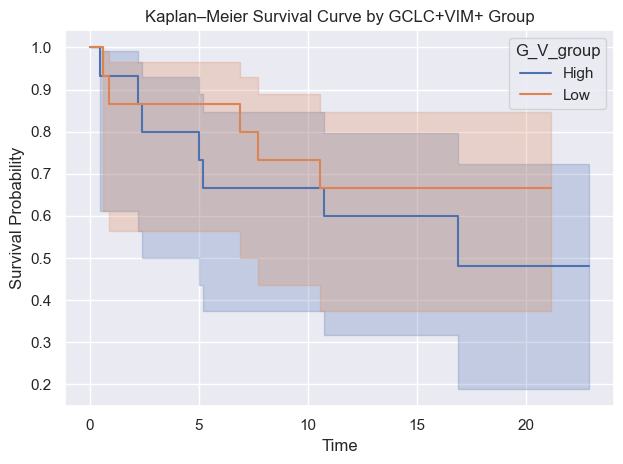

In [ ]:
df = df_clinical_GV.copy()
kmf = KaplanMeierFitter()
fig, ax = plt.subplots()

# Fit the Kaplan-Meier estimator for each group
for group in df['G_V_group'].unique():
    mask = df['G_V_group'] == group
    kmf.fit(df[mask]['time'], df[mask]['status'], label=group)
    kmf.plot_survival_function(ax=ax)

# Customize the plot
plt.title("Kaplan-Meier Survival Curve by GCLC+VIM+ Group")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend(title="G_V_group")
plt.tight_layout()
plt.show()

In [57]:
df_high = df[df['G_V_group'] == 'High']
df_low = df[df['G_V_group'] == 'Low']

# log-rank test
results = logrank_test(
    df_high['time'], df_low['time'],
    event_observed_A=df_high['status'],
    event_observed_B=df_low['status']
)

print("Log-rank test p-value:", results.p_value)

Log-rank test p-value: 0.4730617944628731


# VIM+ECAD+

In [13]:
data_tumor.columns

Index(['S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4', 'FOXP3',
       'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin', 'H3K27me3',
       'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN', 'pSTAT3',
       'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid', 'imageid',
       'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI',
       'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1',
       'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM',
       'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs'],
      dtype='object')

In [17]:
VIM_ECA_data = data_tumor[['core_imageid', 'patient_id_AB19_1654', 'GCLC', 'NQO1', 'Vimentin', 'E.Cadherin']]

VIM_ECA_data['VIM_ECA'] = VIM_ECA_data['GCLC']

VIM_ECA_data.loc[(VIM_ECA_data['Vimentin'] >= 0.5) & (VIM_ECA_data['E.Cadherin'] >= 0.5), 'VIM_ECA'] = 'VIM+E.Cad+'
VIM_ECA_data.loc[(VIM_ECA_data['Vimentin'] < 0.5) & (VIM_ECA_data['E.Cadherin'] >= 0.5), 'VIM_ECA'] = 'VIM-E.Cad+'
VIM_ECA_data.loc[(VIM_ECA_data['Vimentin'] >= 0.5) & (VIM_ECA_data['E.Cadherin'] < 0.5), 'VIM_ECA'] = 'VIM+E.Cad-'
VIM_ECA_data.loc[(VIM_ECA_data['Vimentin'] < 0.5) & (VIM_ECA_data['E.Cadherin'] < 0.5), 'VIM_ECA'] = 'VIM-E.Cad-'

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_27774/351881348.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_27774/351881348.py:5: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'VIM+E.Cad+' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



In [18]:
VIM_ECA_data['VIM_ECA'].value_counts()

VIM_ECA
VIM-E.Cad+    1229458
VIM+E.Cad+     343429
VIM-E.Cad-     163429
VIM+E.Cad-      36844
Name: count, dtype: int64

In [20]:
# Group by patient_id_AB19_1654 and VIM_ECA, and calculate mean GCLC and NQO1
grouped_data = VIM_ECA_data.groupby(['patient_id_AB19_1654', 'VIM_ECA'])[['GCLC', 'NQO1']].mean().reset_index()

# Reshape the data to have patients as rows and VIM_ECA categories as columns
gclc_pivot = grouped_data.pivot(index='patient_id_AB19_1654', columns='VIM_ECA', values='GCLC')
nqo1_pivot = grouped_data.pivot(index='patient_id_AB19_1654', columns='VIM_ECA', values='NQO1')

# Reorder columns in a logical sequence
column_order = ['VIM-E.Cad-', 'VIM-E.Cad+', 'VIM+E.Cad-', 'VIM+E.Cad+']
gclc_pivot = gclc_pivot[column_order]
nqo1_pivot = nqo1_pivot[column_order]

In [24]:
grouped_data

,patient_id_AB19_1654,VIM_ECA,GCLC,NQO1
0,AB19-1654_P10078,VIM+E.Cad+,0.553394,0.407972
1,AB19-1654_P10078,VIM+E.Cad-,0.551921,0.308052
2,AB19-1654_P10078,VIM-E.Cad+,0.288961,0.446085
3,AB19-1654_P10078,VIM-E.Cad-,0.151269,0.215611
4,AB19-1654_P10079,VIM+E.Cad+,0.520632,0.105031
...,...,...,...,...
722,AB19-1654_P10710,VIM-E.Cad-,0.470417,0.466038
723,AB19-1654_P10711,VIM+E.Cad+,0.546316,0.449627
724,AB19-1654_P10711,VIM+E.Cad-,0.530268,0.448702
725,AB19-1654_P10711,VIM-E.Cad+,0.501716,0.450486


In [ ]:


def plot_violin_with_paired_lines(df, value_col, group_col, id_col,
                                   figsize=(8, 6), palette='white',
                                   save_path=None):
    
    #sns.set(style="whitegrid")
    sns.set_style("white")
    fig, ax = plt.subplots(figsize=figsize)

    # Violin plot
    sns.violinplot(x=group_col, y=value_col, data=df, inner=None, ax=ax, color=palette)

    # Narrower boxplot overlay
    sns.boxplot(x=group_col, y=value_col, data=df, ax=ax,
                width=0.1,
                showcaps=True,
                boxprops={'facecolor':'white', 'zorder':2},
                whiskerprops={'linewidth':1.5},
                showfliers=False)
    
    # Strip plot for individual data points
    sns.stripplot(x=group_col, y=value_col, data=df,
              ax=ax, color='black', size=4, alpha=0.6,
              jitter=False, dodge=True)


    # Pairwise lines
    for sample_id, group in df.groupby(id_col):
        if len(group[group_col].unique()) > 1:
            x = [list(df[group_col].unique()).index(g) for g in group[group_col]]
            y = group[value_col].tolist()
            ax.plot(x, y, color='gray', alpha=0.2, zorder=1)

    # Pairwise t-test with actual p-values and significance stars
    groups = df[group_col].unique()
    pairs = list(itertools.combinations(groups, 2))
    y_max = df[value_col].max()
    for i, (g1, g2) in enumerate(pairs):
        data1 = df[df[group_col] == g1][value_col]
        data2 = df[df[group_col] == g2][value_col]
        common_ids = set(df[df[group_col] == g1][id_col]) & set(df[df[group_col] == g2][id_col])
        if len(common_ids) > 1:
            paired1 = df[(df[group_col] == g1) & (df[id_col].isin(common_ids))].sort_values(id_col)[value_col]
            paired2 = df[(df[group_col] == g2) & (df[id_col].isin(common_ids))].sort_values(id_col)[value_col]
            stat, pval = ttest_rel(paired1.values, paired2.values)

            # Determine significance stars
            #if pval < 1e-4:
            #    stars = '****'
            #elif pval < 1e-3:
            #    stars = '***'
            #elif pval < 1e-2:
            #    stars = '**'
            #elif pval < 0.05:
            #    stars = '*'
            #else:
            #    stars = 'ns'

            
            x1, x2 = groups.tolist().index(g1), groups.tolist().index(g2)
            y = y_max + 0.04 + i * 0.05
            h = 0.01
            ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')

            # Add p-value text
            #p_text = f"p = {pval:.1e} {stars}"
            p_text = f"p = {pval:.1e}"
            xpos = (groups.tolist().index(g1) + groups.tolist().index(g2)) / 2
            ax.text(xpos, y_max + 0.05 + i * 0.05, p_text,
                    ha='center', va='bottom', fontsize=10)

    #ax.set_title(value_col)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300)
        print(f"Figure saved to {save_path}")

    return fig


In [54]:
df_data = grouped_data[grouped_data['VIM_ECA'].isin(['VIM+E.Cad+', 'VIM+E.Cad-', 'VIM-E.Cad+'])]

Figure saved to /Users/wenqchen/Desktop/Projects/Auria/Plots/VIM_ECAN/GCLC_violin.pdf


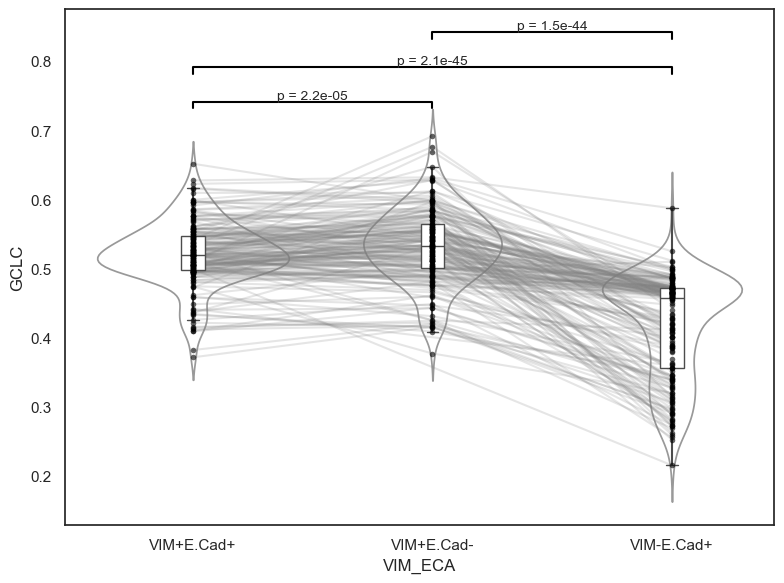

In [59]:

plot_violin_with_paired_lines(df=df_data, value_col='GCLC', group_col='VIM_ECA', id_col='patient_id_AB19_1654',
                              figsize=(8, 6), palette='white',
                              save_path='/Users/wenqchen/Desktop/Projects/Auria/Plots/VIM_ECAN/GCLC_violin.pdf')
plt.tight_layout()
plt.show()

Figure saved to /Users/wenqchen/Desktop/Projects/Auria/Plots/VIM_ECAN/NQO1_violin.pdf


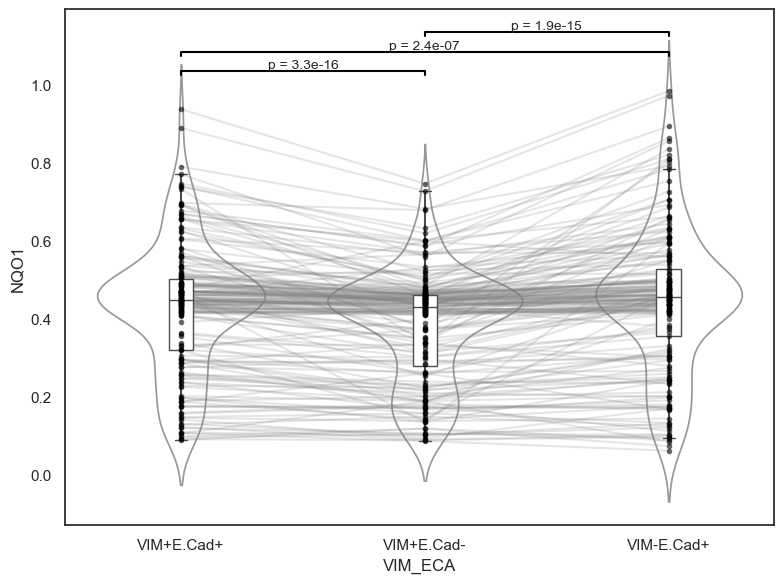

In [60]:
plot_violin_with_paired_lines(df=df_data, value_col='NQO1', group_col='VIM_ECA', id_col='patient_id_AB19_1654',
                              figsize=(8, 6), palette='white',
                              save_path='/Users/wenqchen/Desktop/Projects/Auria/Plots/VIM_ECAN/NQO1_violin.pdf')
plt.tight_layout()
plt.show()